In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers shap scikit-learn -q
print("✅ 依赖安装完成")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 依赖安装完成


In [2]:
import pandas as pd
import numpy as np
import torch
import shap
import matplotlib.pyplot as plt
from transformers import (DistilBertTokenizer,
                          DistilBertForSequenceClassification,
                          Trainer, TrainingArguments)
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

print(f"GPU: {torch.cuda.is_available()}")

GPU: True


In [3]:
DATA_FAKE = '/content/drive/MyDrive/IS6423 Group Project/Data/Fake.csv'
DATA_TRUE = '/content/drive/MyDrive/IS6423 Group Project/Data/True.csv'

fake = pd.read_csv(DATA_FAKE)
true = pd.read_csv(DATA_TRUE)
fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true], ignore_index=True).sample(frac=1, random_state=42)

# !! 不做任何清洗，直接构造输入 !!
df['input_text'] = (
    df['title'].fillna('') + ' [SEP] ' +
    df['text'].fillna('').apply(lambda x: ' '.join(str(x).split()[:100]))
)

print(f"总样本数: {len(df)}")
print(df['label'].value_counts())
print("\n样本预览（注意Reuters标识是否还在）:")
print(df[df['label']==1]['input_text'].iloc[0][:300])

总样本数: 44898
label
0    23481
1    21417
Name: count, dtype: int64

样本预览（注意Reuters标识是否还在）:
Trump drops Steve Bannon from National Security Council [SEP] WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedente


In [4]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = DistilBertTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN    = 256

X = df['input_text'].tolist()
y = df['label'].tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Val: {len(X_val)}")

class NewsDataset(Dataset):
    def __init__(self, texts, labels):
        enc = tokenizer(texts, max_length=MAX_LEN,
                        padding='max_length', truncation=True,
                        return_tensors='pt')
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels         = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {'input_ids':      self.input_ids[idx],
                'attention_mask': self.attention_mask[idx],
                'labels':         self.labels[idx]}

train_dataset = NewsDataset(X_train, y_train)
val_dataset   = NewsDataset(X_val,   y_val)
print("✅ Dataset 构建完成")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 40408 | Val: 4490
✅ Dataset 构建完成


In [5]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'accuracy': accuracy_score(labels, preds),
            'f1':       f1_score(labels, preds, average='weighted')}

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2)

training_args = TrainingArguments(
    output_dir                  = './results_uncleaned',
    num_train_epochs            = 1,          # 只跑1个epoch
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    learning_rate               = 2e-5,
    warmup_steps                = 200,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',
    save_strategy               = 'no',       # 不保存checkpoint，节省时间
    logging_steps               = 100,
    report_to                   = 'none'
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics
)

trainer.train()
# 预期结果：1个epoch准确率接近100%，印证数据泄露

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.009061,0.002338,0.999109,0.999109


TrainOutput(global_step=2526, training_loss=0.02775877807676491, metrics={'train_runtime': 1060.7483, 'train_samples_per_second': 38.094, 'train_steps_per_second': 2.381, 'total_flos': 2676371322445824.0, 'train_loss': 0.02775877807676491, 'epoch': 1.0})

In [6]:
UNCLEANED_MODEL_PATH = '/content/drive/MyDrive/IS6423 Group Project/fake_news_uncleaned'

model.save_pretrained(UNCLEANED_MODEL_PATH)
tokenizer.save_pretrained(UNCLEANED_MODEL_PATH)
print(f"✅ 未清洗模型已保存至 {UNCLEANED_MODEL_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 未清洗模型已保存至 /content/drive/MyDrive/IS6423 Group Project/fake_news_uncleaned


In [7]:
model.eval()
model.to('cuda')

# 准备SHAP样本：各取50条，共100条
shap_samples = pd.concat([
    df[df['label']==0].sample(50, random_state=42),
    df[df['label']==1].sample(50, random_state=42)
]).reset_index(drop=True)

texts = shap_samples['input_text'].tolist()

def predict_proba(texts):
    results = []
    for i in range(0, len(texts), 8):
        batch = list(texts[i:i+8])
        inputs = tokenizer(batch, return_tensors='pt', max_length=256,
                           truncation=True, padding=True)
        inputs = {k: v.to('cuda') for k, v in inputs.items()}
        with torch.no_grad():
            logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        results.extend(probs)
    return np.array(results)

explainer = shap.Explainer(
    predict_proba,
    masker       = shap.maskers.Text(tokenizer),
    output_names = ['Fake', 'Real']
)

print("✅ Explainer 创建成功，开始计算 SHAP 值（约10分钟）...")
shap_values = explainer(texts)
print("✅ SHAP 值计算完成")

✅ Explainer 创建成功，开始计算 SHAP 值（约10分钟）...


PartitionExplainer explainer: 101it [04:43,  2.89s/it]

✅ SHAP 值计算完成


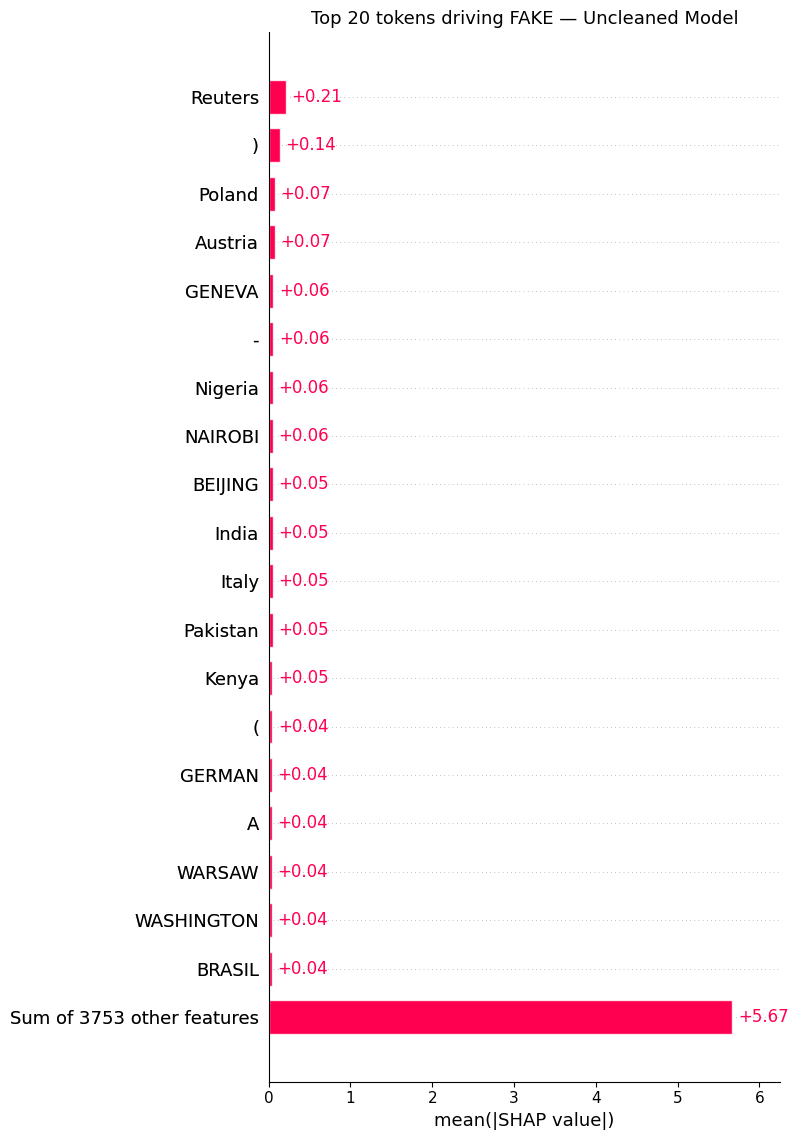

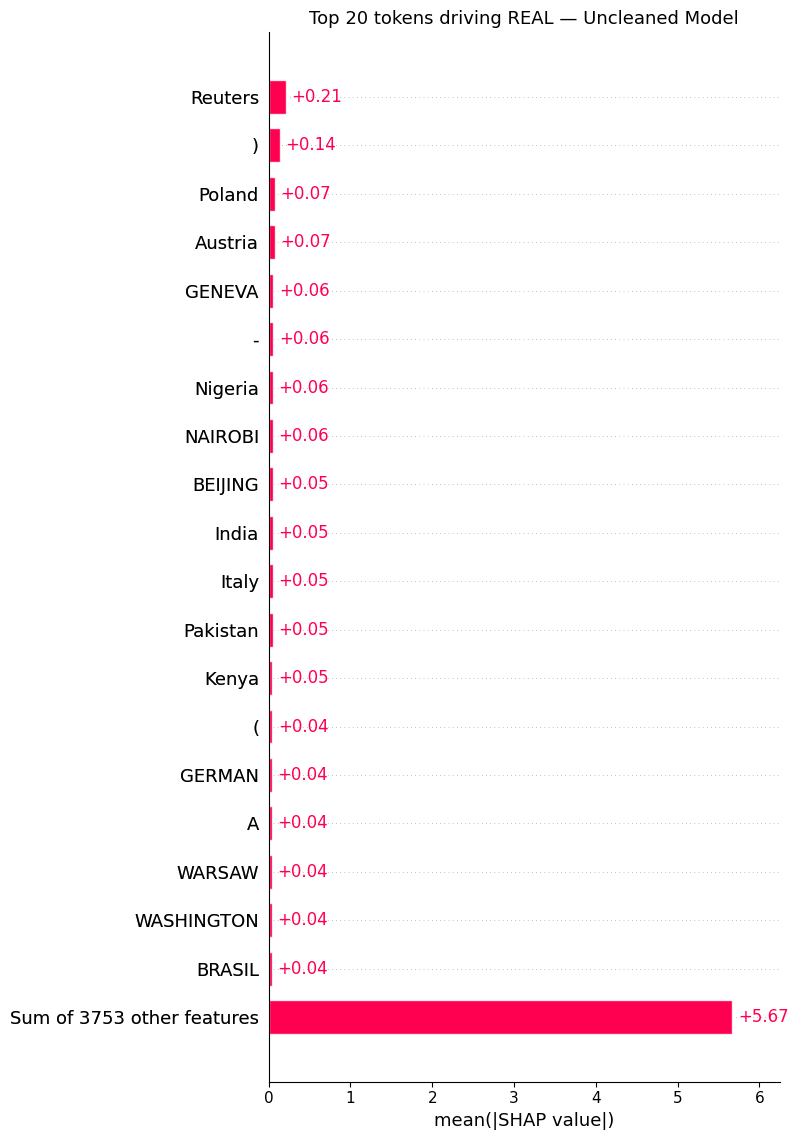

=== 真新闻样本 token-level 解释 ===


=== 假新闻样本 token-level 解释 ===


In [9]:
SAVE_PATH = '/content/drive/MyDrive/IS6423 Group Project'

# Bar chart — Fake 类别
shap.plots.bar(shap_values[:, :, 0], max_display=20, show=False)
plt.title('Top 20 tokens driving FAKE — Uncleaned Model', fontsize=13)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'shap_bar_fake_uncleaned.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart — Real 类别
shap.plots.bar(shap_values[:, :, 1], max_display=20, show=False)
plt.title('Top 20 tokens driving REAL — Uncleaned Model', fontsize=13)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'shap_bar_real_uncleaned.png', dpi=150, bbox_inches='tight')
plt.show()

# 单条文本解释
print("=== 真新闻样本 token-level 解释 ===")
real_idx = shap_samples[shap_samples['label']==1].index[0]
shap.plots.text(shap_values[real_idx])

print("=== 假新闻样本 token-level 解释 ===")
fake_idx = shap_samples[shap_samples['label']==0].index[0]
shap.plots.text(shap_values[fake_idx])

In [10]:
import collections

fake_token_scores = collections.defaultdict(list)
real_token_scores = collections.defaultdict(list)

STOPWORDS = {'the','a','an','is','are','was','were','be','been',
             'to','of','in','and','or','it','its','this','that',
             'for','on','at','by','as','with','from','have','has'}

for i in range(len(shap_values)):
    tokens = shap_values[i].data
    values = shap_values[i].values
    for token, val in zip(tokens, values):
        token = token.strip()
        if (len(token) < 3 or
            token.lower() in STOPWORDS or
            token.startswith('##')):
            continue
        fake_token_scores[token].append(val[0])
        real_token_scores[token].append(val[1])

def get_top_tokens(token_scores, top_n=15, min_count=3):
    averaged = {t: np.mean(s) for t, s in token_scores.items()
                if len(s) >= min_count}
    return sorted(averaged.items(), key=lambda x: x[1], reverse=True)[:top_n]

print("=== 最强 FAKE 信号词（未清洗模型）===")
for token, score in get_top_tokens(fake_token_scores):
    print(f"  {token:<20} avg SHAP = {score:+.4f}")

print("\n=== 最强 REAL 信号词（未清洗模型）===")
for token, score in get_top_tokens(real_token_scores):
    print(f"  {token:<20} avg SHAP = {score:+.4f}")

=== 最强 FAKE 信号词（未清洗模型）===
  Video                avg SHAP = +0.0129
  VIDEO                avg SHAP = +0.0114
  Mike                 avg SHAP = +0.0077
  WEE                  avg SHAP = +0.0064
  Ryan                 avg SHAP = +0.0049
  Michael              avg SHAP = +0.0048
  Twitter              avg SHAP = +0.0047
  Anti                 avg SHAP = +0.0042
  News                 avg SHAP = +0.0042
  friend               avg SHAP = +0.0039
  Just                 avg SHAP = +0.0038
  ted                  avg SHAP = +0.0037
  Steele               avg SHAP = +0.0035
  Obama                avg SHAP = +0.0034
  wee                  avg SHAP = +0.0034

=== 最强 REAL 信号词（未清洗模型）===
  Reuters              avg SHAP = +0.2057
  Pakistan             avg SHAP = +0.0472
  WASHINGTON           avg SHAP = +0.0370
  Former               avg SHAP = +0.0280
  Brazil               avg SHAP = +0.0249
  Taiwan               avg SHAP = +0.0249
  Iraq                 avg SHAP = +0.0237
  British              